
# Лабораторная работа 2
## Обнаружение аномалий в данных

## Цель работы
1. Освоить методы обнаружения выбросов на основе статистических критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом предметной области.


## Задание 1. Загрузка и профилирование данных


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('../data/bank.csv', sep=';')
print("Данные загружены. Размер датасета:", df.shape)

print("--- df.info() ---")
df.info()

print("\n--- df.describe() ---")
display(df.describe())

Данные загружены. Размер датасета: (4521, 16)
--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4488 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   3306 non-null   object
dtypes: int64(7), object(9)
memory usage: 565.3+ KB

--- df.describe() ---


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,261.088034,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,262.745220,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,-1721.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,328.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [25]:

print(" Пропуски в данных ")
missing_data = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков, %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data)

 Пропуски в данных 
           Количество пропусков  Доля пропусков, %
age                           0               0.00
job                           0               0.00
marital                       0               0.00
education                     0               0.00
default                       0               0.00
balance                       0               0.00
housing                       0               0.00
loan                          0               0.00
contact                      33               0.73
day                           0               0.00
month                         0               0.00
duration                      0               0.00
campaign                      0               0.00
pdays                         0               0.00
previous                      0               0.00
poutcome                   1215              26.87


In [28]:
numeric_cols = ['age', 'balance', 'duration',]

for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Диапазон: [{df[col].min():.0f}, {df[col].max():.0f}]")

    if col == 'balance':
        negative = (df[col] < 0).sum()
        zero = (df[col] == 0).sum()
        print(f"  Отрицательные значения (возможные долги): {negative}")
        print(f"  Нулевые значения: {zero}")
    
    if col == 'duration':
        negative = (df[col] < 0).sum()
        print(f"  Отрицательные значения (ошибка измерения): {negative}")


age:
  Диапазон: [19, 87]

balance:
  Диапазон: [-3313, 71188]
  Отрицательные значения (возможные долги): 366
  Нулевые значения: 357

duration:
  Диапазон: [-1721, 3025]
  Отрицательные значения (ошибка измерения): 22


 Вывод по пропускам:
 1. Признак 'contact' имеет 33 пропуска (0.73%). Это не критично.
 2. Признак 'poutcome' имеет 1215 пропусков (26.87%). Это существенно.
   В первой работе было установлено, что пропуски, скорее всего, имеют природу MAR,
   так как зависят от типа контакта ('contact').

 ### Анализ числовых признаков
 Выберем два числовых признака для визуального анализа:
 1. balance - баланс на счету клиента (абсолютная шкала)
 2. duration - длительность последнего звонка (абсолютная шкала)

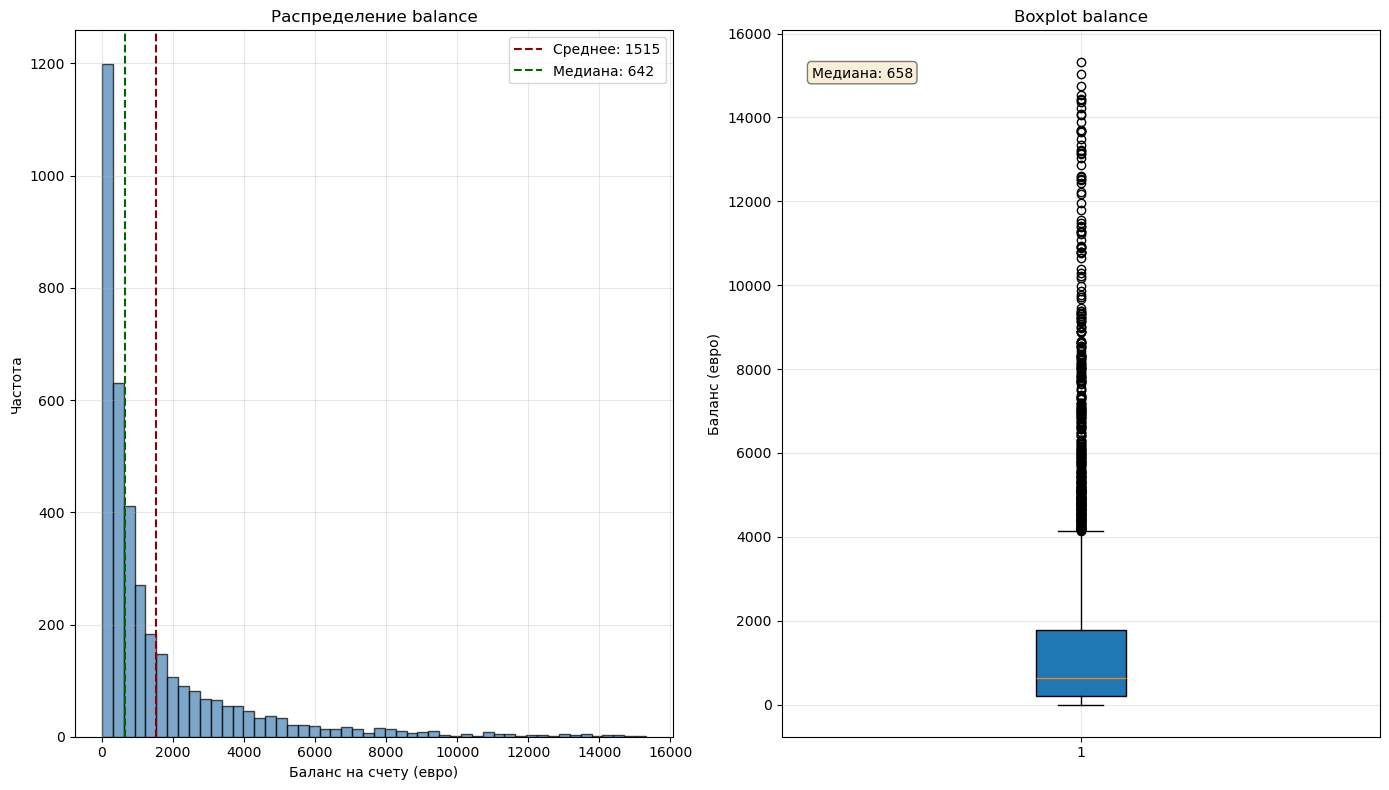

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

balance_pos = df['balance'][df['balance'] > 0]
q99_balance = balance_pos.quantile(0.99)
balance_filtered = balance_pos[balance_pos <= q99_balance]

axes[0].hist(balance_filtered, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(balance_filtered.mean(), color='darkred', linestyle='--', 
                   label=f'Среднее: {balance_filtered.mean():.0f}')
axes[0].axvline(balance_filtered.median(), color='darkgreen', linestyle='--', 
                   label=f'Медиана: {balance_filtered.median():.0f}')
axes[0].set_title('Распределение balance')
axes[0].set_xlabel('Баланс на счету (евро)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bp1 = axes[1].boxplot(balance_pos[balance_pos <= q99_balance], vert=True, patch_artist=True)
axes[1].set_title('Boxplot balance')
axes[1].set_ylabel('Баланс (евро)')
axes[1].grid(True, alpha=0.3)
stats_text = f"Медиана: {balance_pos.median():.0f}"
axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


plt.tight_layout()
plt.show()

### Вывод по balance:
 Распределение сильно асимметрично вправо (много клиентов с низким балансом,несколько - с очень высоким).
 На boxplot видно множество выбросов (точек за пределами усов). Это может быть связано как с реальными "VIP-клиентами",так и с потенциальными ошибками ввода.

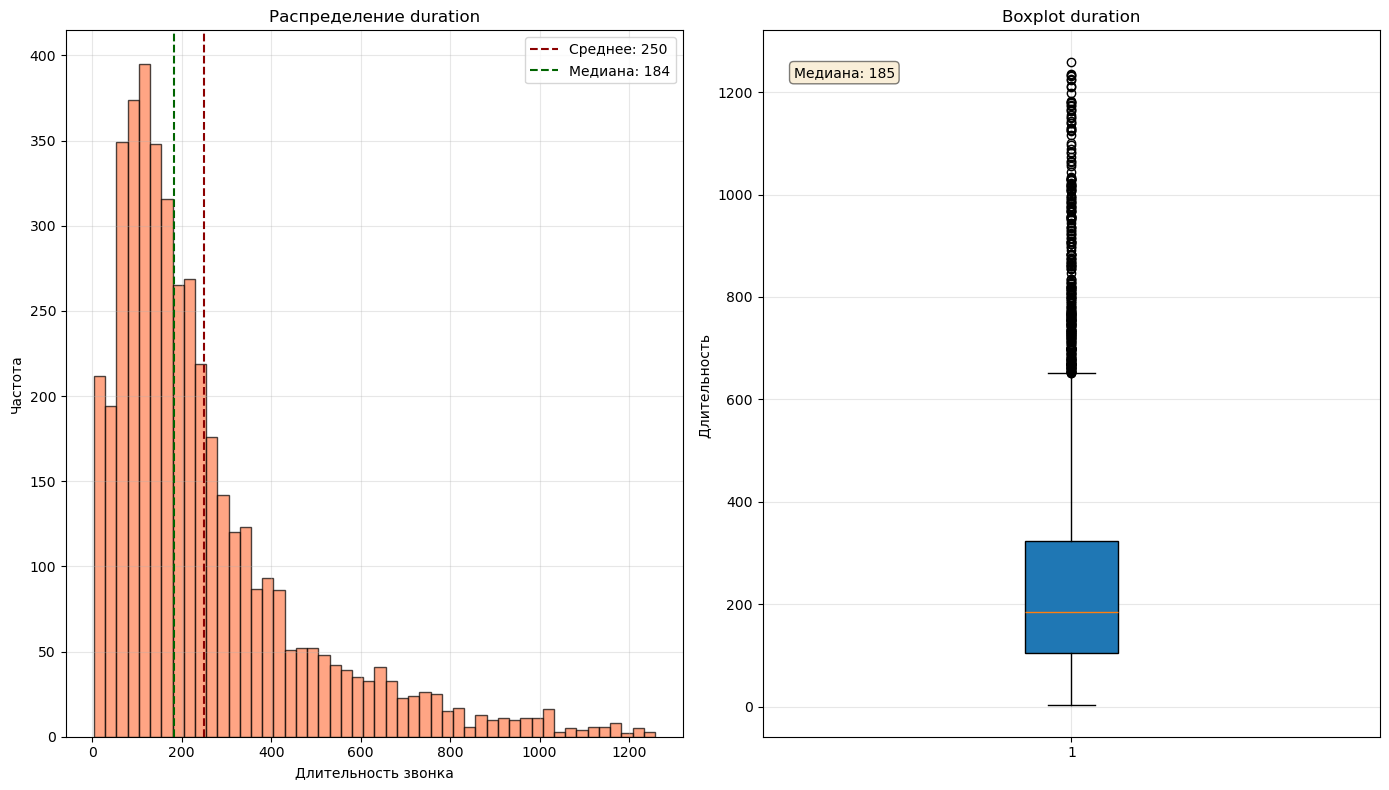

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
duration_pos = df['duration'][df['duration'] >= 0]
q99_duration = duration_pos.quantile(0.99)
duration_filtered = duration_pos[duration_pos <= q99_duration]

axes[0].hist(duration_filtered, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(duration_filtered.mean(), color='darkred', linestyle='--', 
                   label=f'Среднее: {duration_filtered.mean():.0f}')
axes[0].axvline(duration_filtered.median(), color='darkgreen', linestyle='--', 
                   label=f'Медиана: {duration_filtered.median():.0f}')
axes[0].set_title('Распределение duration')
axes[0].set_xlabel('Длительность звонка')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

bp2 = axes[1].boxplot(duration_pos[duration_pos <= q99_duration], vert=True, patch_artist=True)
axes[1].set_title('Boxplot duration')
axes[1].set_ylabel('Длительность ')
axes[1].grid(True, alpha=0.3)
stats_text = f"Медиана: {duration_pos.median():.0f}"
axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


 ### Вывод по duration:
 
Распределение асимметрично вправо: большинство звонков короткие (< 500 сек),но есть и очень длительные.
Boxplot показывает наличие выбросов (очень длинных звонков).
Также в данных есть отрицательные значения длительности, что является аномалией и, вероятно, ошибкой измерения. Это нужно будет учесть при анализе.

## Задание 2. Проверка нормальности распределения
Проверим нормальность распределения для признаков `balance` и `duration`.

In [51]:

balance_data = df['balance'][df['balance'] > 0].copy()
duration_data = df['duration'][df['duration'] >= 0].copy()  # Исключаем отрицательные значения

print(f"Анализ для balance (n={len(balance_data)}):")
print(f"  Среднее: {balance_data.mean():.2f}")
print(f"  Медиана: {balance_data.median():.2f}")
print(f"  Стандартное отклонение: {balance_data.std():.2f}")
print(f"  Коэффициент асимметрии: {balance_data.skew():.2f}")
print(f"  Коэффициент эксцесса: {balance_data.kurtosis():.2f}")

print(f"\nАнализ для duration (n={len(duration_data)}):")
print(f"  Среднее: {duration_data.mean():.2f}")
print(f"  Медиана: {duration_data.median():.2f}")
print(f"  Стандартное отклонение: {duration_data.std():.2f}")
print(f"  Коэффициент асимметрии: {duration_data.skew():.2f}")
print(f"  Коэффициент эксцесса: {duration_data.kurtosis():.2f}")

Анализ для balance (n=3798):
  Среднее: 1725.23
  Медиана: 658.50
  Стандартное отклонение: 3192.62
  Коэффициент асимметрии: 6.32
  Коэффициент эксцесса: 80.47

Анализ для duration (n=4499):
  Среднее: 263.81
  Медиана: 185.00
  Стандартное отклонение: 258.55
  Коэффициент асимметрии: 2.76
  Коэффициент эксцесса: 12.54


### Графический анализ: QQ-графики
QQ-график (Quantile-Quantile plot) позволяет сравнить распределение выборки с теоретическим нормальным распределением.

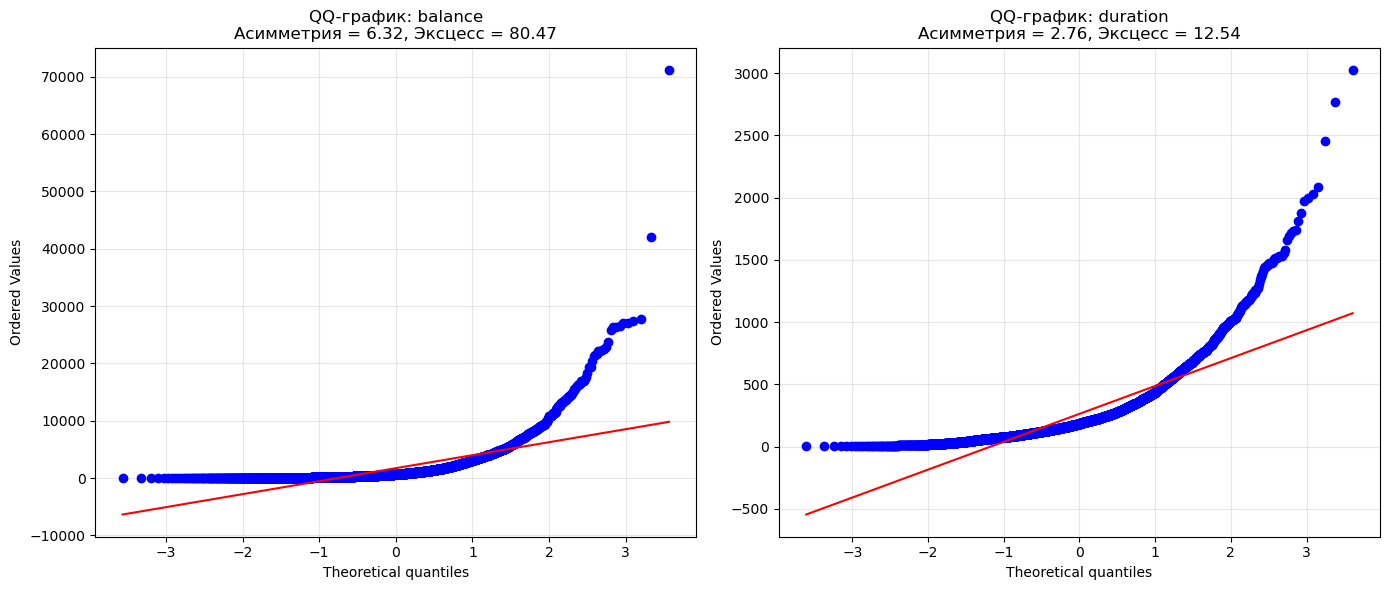

Распределения значительно отличаются от нормального, коэффициенты асимметрии и эксцесса принимают большие значения.
Отличие распределений от нормального объясняется спецификой банковских данных:
1) balance имеет длинный правый хвост из-за небольшого числа клиентов с высокими сбережениями
2) duration имеет длинный правый хвост из-за редких, но очень длительных разговоров с клиентами
Распределение параметра duration визуально ближе к нормальному, но всё еще сильно отличается от него.


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
stats.probplot(balance_clean, dist="norm", plot=axes[0])
skew_b = balance_clean.skew()
kurt_b = balance_clean.kurtosis()
axes[0].set_title(f'QQ-график: balance\nАсимметрия = {skew_b:.2f}, Эксцесс = {kurt_b:.2f}')
axes[0].grid(True, alpha=0.3)

stats.probplot(duration_clean, dist="norm", plot=axes[1])
skew_d = duration_clean.skew()
kurt_d = duration_clean.kurtosis()
axes[1].set_title(f'QQ-график: duration\nАсимметрия = {skew_d:.2f}, Эксцесс = {kurt_d:.2f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Распределения значительно отличаются от нормального, коэффициенты асимметрии и эксцесса принимают большие значения.")
print("Отличие распределений от нормального объясняется спецификой банковских данных:")
print("1) balance имеет длинный правый хвост из-за небольшого числа клиентов с высокими сбережениями")
print("2) duration имеет длинный правый хвост из-за редких, но очень длительных разговоров с клиентами")
print("Распределение параметра duration визуально ближе к нормальному, но всё еще сильно отличается от него.")

### Проверка нормальности с помощью критерия Шапиро-Уилка

**Гипотезы:**
- H₀: выборка подчиняется нормальному распределению
- H₁: выборка не подчиняется нормальному распределению

Уровень значимости: α = 0.05

In [12]:
balance_sample = balance_data.sample(n=5000, random_state=42) if len(balance_data) > 5000 else balance_data
duration_sample = duration_data.sample(n=5000, random_state=42) if len(duration_data) > 5000 else duration_data

shapiro_balance = stats.shapiro(balance_sample)
shapiro_duration = stats.shapiro(duration_sample)

print(f"Критерий Шапиро-Уилка для balance:")
print(f"  Статистика W = {shapiro_balance[0]:.4f}")
print(f"  p-value = {shapiro_balance[1]:.4e}")
if shapiro_balance[1] < 0.05:
    print("  => p-value < 0.05. Отвергаем H₀. Распределение НЕ является нормальным.")
else:
    print("  => p-value >= 0.05. Нет оснований отвергнуть H₀. Распределение может быть нормальным.")

print(f"\nКритерий Шапиро-Уилка для duration:")
print(f"  Статистика W = {shapiro_duration[0]:.4f}")
print(f"  p-value = {shapiro_duration[1]:.4e}")
if shapiro_duration[1] < 0.05:
    print("  => p-value < 0.05. Отвергаем H₀. Распределение НЕ является нормальным.")
else:
    print("  => p-value >= 0.05. Нет оснований отвергнуть H₀. Распределение может быть нормальным.")

Критерий Шапиро-Уилка для balance:
  Статистика W = 0.5054
  p-value = 1.9719e-73
  => p-value < 0.05. Отвергаем H₀. Распределение НЕ является нормальным.

Критерий Шапиро-Уилка для duration:
  Статистика W = 0.7498
  p-value = 1.1811e-63
  => p-value < 0.05. Отвергаем H₀. Распределение НЕ является нормальным.


**Вывод по проверке нормальности:**
Оба признака (balance и duration) имеют распределения, которые значительно отличаются от нормального. Это подтверждается:
1. Значениями асимметрии и эксцесса, далекими от нуля.
2. Отклонениями на QQ-графиках от прямой линии.
3. Результатами теста Шапиро-Уилка (p-value << 0.05).

Для таких распределений использование методов обнаружения выбросов, основанных на нормальности (например, Z-score), может быть неоптимальным.

**Выбор признака для дальнейших методов:**
Из двух признаков duration имеет распределение, которое визуально ближе к нормальному, чем balance. Для метода Z-score и IQR, мы будем использовать duration (предварительно очистив от отрицательных значений). Метод IQR более устойчив к форме распределения и будет применен к обоим признакам.

## Задание 3. Обнаружение выбросов статистическими методами
Будем использовать признак `duration` (очищенный от отрицательных значений).

In [13]:
data_duration = df['duration'][df['duration'] >= 0].copy()
print(f"Данные для анализа: {len(data_duration)} записей.")
print(f"Диапазон: [{data_duration.min():.0f}, {data_duration.max():.0f}]")

Данные для анализа: 4499 записей.
Диапазон: [4, 3025]


### 1. Метод Z-score
Z-оценка показывает, на сколько стандартных отклонений значение отклоняется от среднего.
Аномалией будем считать точки, для которых |Z| > 3.

Среднее: 263.81
Стандартное отклонение: 258.55
Количество выбросов (|Z| > 3): 86
Доля выбросов: 1.91%
Диапазон выбросов: [1044, 3025]


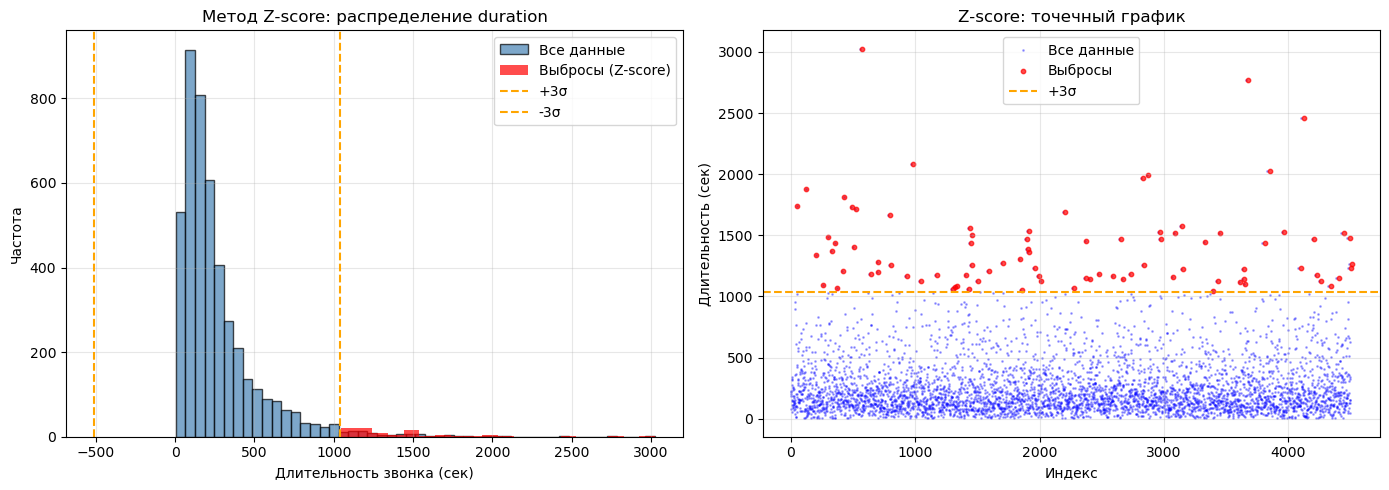

In [63]:
mean_val = data.mean()
std_val = data.std()
z_scores = np.abs((data - mean_val) / std_val)
outliers_z = data[z_scores > 3]

print(f"Среднее: {mean_val:.2f}")
print(f"Стандартное отклонение: {std_val:.2f}")
print(f"Количество выбросов (|Z| > 3): {len(outliers_z)}")
print(f"Доля выбросов: {len(outliers_z)/len(data)*100:.2f}%")
print(f"Диапазон выбросов: [{outliers_z.min():.0f}, {outliers_z.max():.0f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black', label='Все данные')
axes[0].hist(outliers_z, bins=20, alpha=0.7, color='red', label='Выбросы (Z-score)')
axes[0].axvline(mean_val + 3*std_val, color='orange', linestyle='--', label='+3σ')
axes[0].axvline(mean_val - 3*std_val, color='orange', linestyle='--', label='-3σ')
axes[0].set_title('Метод Z-score: распределение duration')
axes[0].set_xlabel('Длительность звонка (сек)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(len(data)), data, alpha=0.3, s=1, c='blue', label='Все данные')
axes[1].scatter(outliers_z.index, outliers_z, alpha=0.7, s=10, c='red', label='Выбросы')
axes[1].axhline(mean_val + 3*std_val, color='orange', linestyle='--', label='+3σ')
axes[1].set_title('Z-score: точечный график')
axes[1].set_xlabel('Индекс')
axes[1].set_ylabel('Длительность (сек)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Метод IQR 
Аномалии определяются как точки, выходящие за пределы интервала [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR].

Q1 (25-й перцентиль): 104.00
Q3 (75-й перцентиль): 329.50
IQR: 225.50
Нижняя граница: -234.25
Верхняя граница: 667.75
Количество выбросов: 327
Доля выбросов: 7.27%


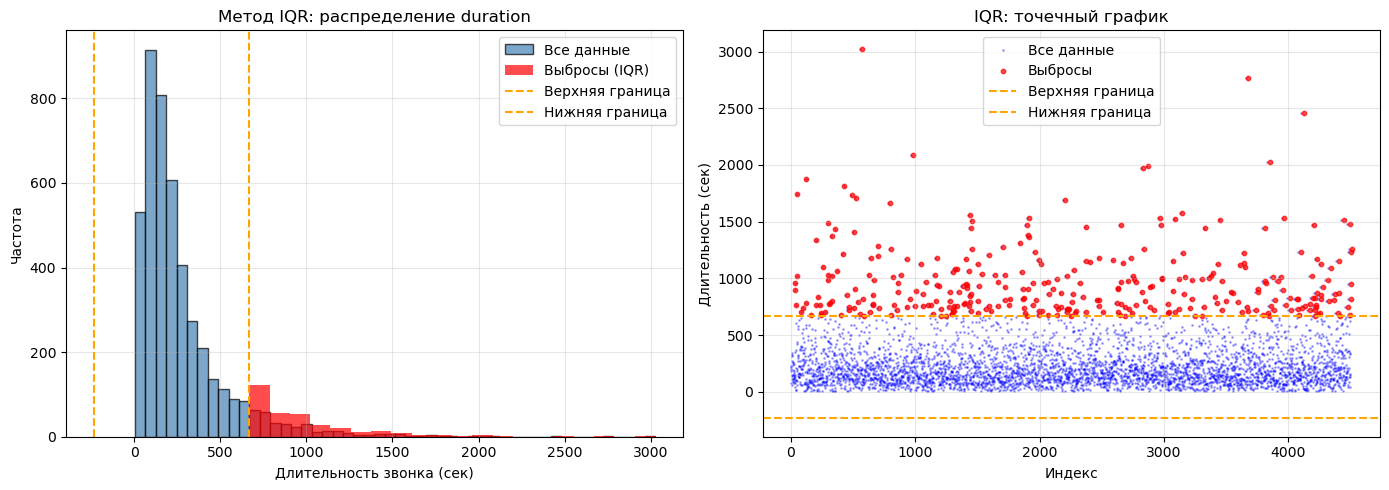

In [64]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]

print(f"Q1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers_iqr)}")
print(f"Доля выбросов: {len(outliers_iqr)/len(data)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black', label='Все данные')
axes[0].hist(outliers_iqr, bins=20, alpha=0.7, color='red', label='Выбросы (IQR)')
axes[0].axvline(upper_bound, color='orange', linestyle='--', label=f'Верхняя граница')
axes[0].axvline(lower_bound, color='orange', linestyle='--', label=f'Нижняя граница')
axes[0].set_title('Метод IQR: распределение duration')
axes[0].set_xlabel('Длительность звонка (сек)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 4: Scatter plot с IQR
axes[1].scatter(range(len(data)), data, alpha=0.3, s=1, c='blue', label='Все данные')
axes[1].scatter(outliers_iqr.index, outliers_iqr, alpha=0.7, s=10, c='red', label='Выбросы')
axes[1].axhline(upper_bound, color='orange', linestyle='--', label='Верхняя граница')
axes[1].axhline(lower_bound, color='orange', linestyle='--', label='Нижняя граница')
axes[1].set_title('IQR: точечный график')
axes[1].set_xlabel('Индекс')
axes[1].set_ylabel('Длительность (сек)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
print(f"\n{'Метод':<15} {'Количество выбросов':<20} {'Доля':<10}")
print("-"*45)
print(f"{'Z-score (|Z|>3)':<15} {len(outliers_z):<20} {len(outliers_z)/len(data)*100:.2f}%")
print(f"{'IQR (1.5*IQR)':<15} {len(outliers_iqr):<20} {len(outliers_iqr)/len(data)*100:.2f}%")

common = set(outliers_z.index) & set(outliers_iqr.index)

if len(outliers_z) > len(outliers_iqr):
    print("\nМетод Z-score обнаружил больше выбросов, чем IQR")
else:
    print("\nМетод IQR обнаружил больше выбросов, чем Z-score")

print("\nВывод: Метод IQR более робастен и подходит для асимметричных распределений.")


Метод           Количество выбросов  Доля      
---------------------------------------------
Z-score (|Z|>3) 86                   1.91%
IQR (1.5*IQR)   327                  7.27%

Метод IQR обнаружил больше выбросов, чем Z-score

Вывод: Метод IQR более робастен и подходит для асимметричных распределений.


### Сравнительный анализ методов

| Метод | Количество выбросов | Доля | Преимущества | Недостатки |
|-------|---------------------|------|--------------|------------|
| **Z-score** | 86 | 1.91% | - Прост в расчете и интерпретации<br>- Хорошо работает для нормального распределения | - Чувствителен к выбросам (сами выбросы влияют на среднее)<br>- Неэффективен для асимметричных распределений |
| **IQR** | 327 | 7.27% | - Устойчив к выбросам<br>- Не требует нормальности распределения<br>- Прост в интерпретации | <br>- Не учитывает форму распределения |

## Задание 4. Метод локальной плотности (на основе расстояний)
Для обнаружения аномалий этим методом используем оба признака: balance и duration. Предварительно выполним масштабирование.

In [71]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

df_clean = df[['balance', 'duration']].copy()
df_clean = df_clean[(df_clean['balance'] > 0) & (df_clean['duration'] >= 0)]
df_clean = df_clean.dropna()

print(f"Текущая метрика: manhattan")
print(f"Текущий метод: kth")

upper_balance = df_clean['balance'].quantile(0.99)
upper_duration = df_clean['duration'].quantile(0.99)
df_clean['balance'] = np.where(df_clean['balance'] > upper_balance, upper_balance, df_clean['balance'])
df_clean['duration'] = np.where(df_clean['duration'] > upper_duration, upper_duration, df_clean['duration'])

df_unique = df_clean.drop_duplicates().copy()

X = df_unique[['balance', 'duration']].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Размер данных для анализа: {X_scaled.shape}")

Текущая метрика: manhattan
Текущий метод: kth
Размер данных для анализа: (3772, 2)



### 1. Расстояние до k-го соседа и среднее расстояние до k соседей

Для k = 5, 7, 9, 10 вычислим метрики аномальности и определим аномалии как верхние 5% значений.

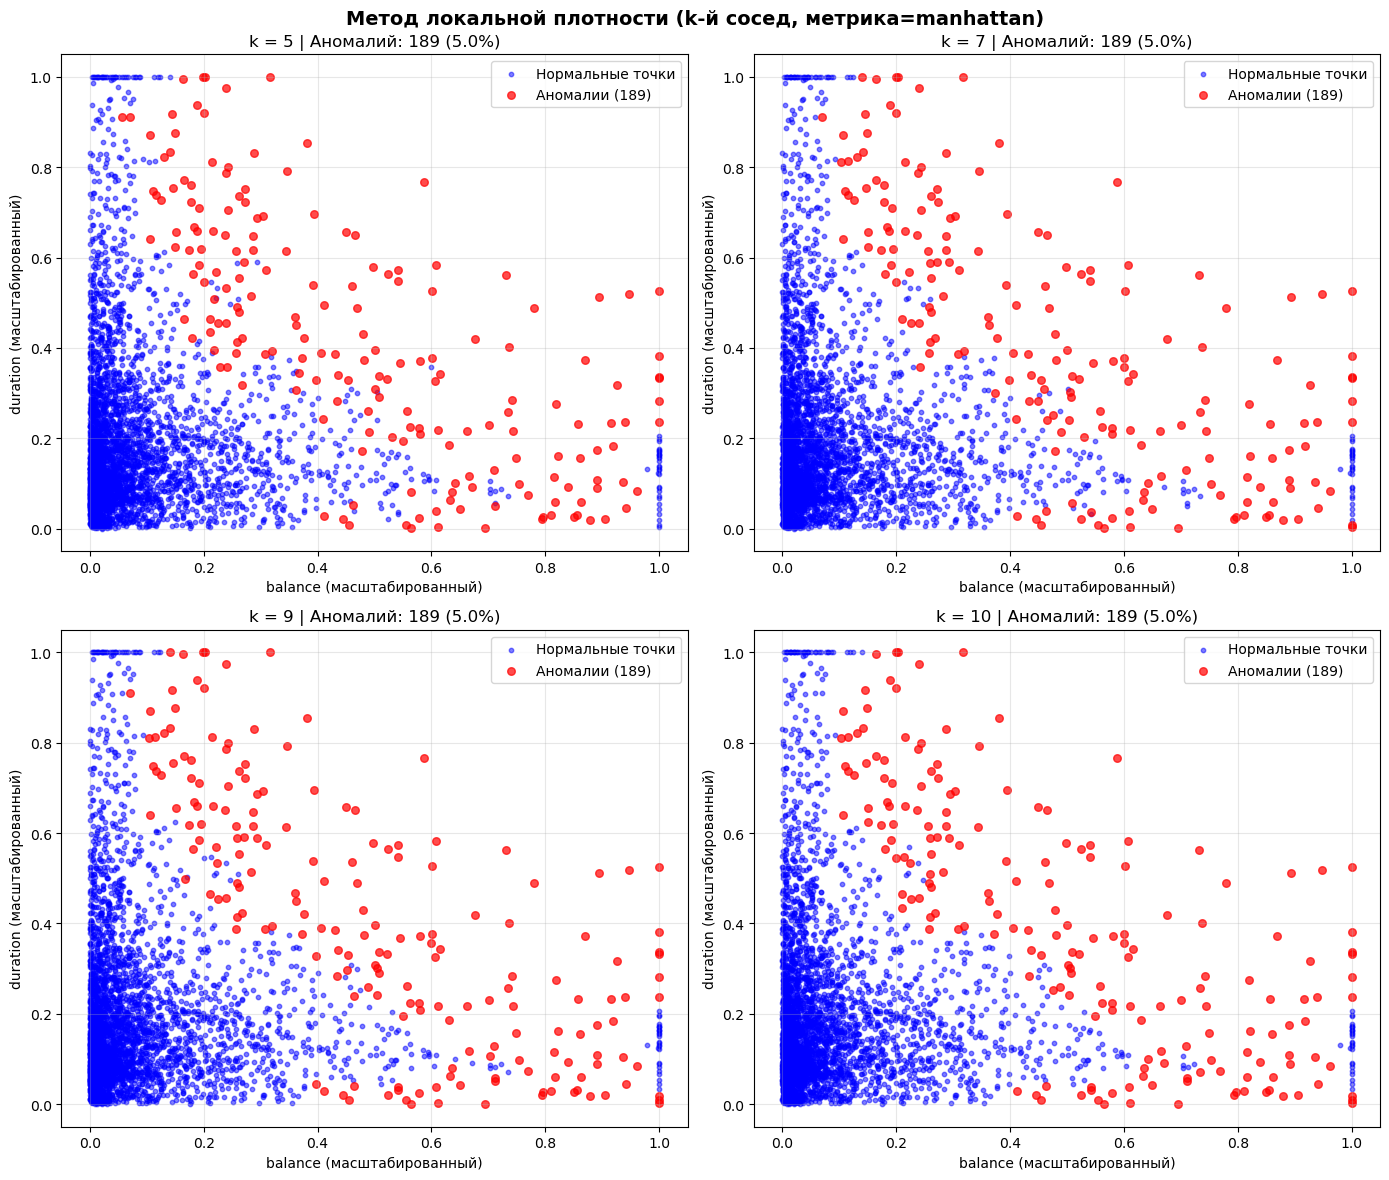

In [74]:
def find_knn_anomalies_kth(X, k, alpha=0.05, metric='manhattan'):
    """Находит аномалии по расстоянию до k-го соседа"""
    neigh = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    scores = distances[:, -1]
    threshold = np.percentile(scores, (1 - alpha) * 100)
    anomalies = scores > threshold
    return anomalies, scores, threshold

k_values = [5, 7, 9, 10]
alpha = 0.05
metric = 'manhattan'

results = {}
scores_dict = {}
thresholds = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, k in enumerate(k_values):
    anomalies, scores, thresh = find_knn_anomalies_kth(X_scaled, k, alpha, metric)
    results[k] = anomalies.sum()
    scores_dict[k] = scores
    thresholds[k] = thresh
    
    ax = axes[i]
    ax.scatter(X_scaled[~anomalies, 0], X_scaled[~anomalies, 1], 
               c='blue', s=10, alpha=0.5, label='Нормальные точки')
    ax.scatter(X_scaled[anomalies, 0], X_scaled[anomalies, 1], 
               c='red', s=30, alpha=0.7, label=f'Аномалии ({anomalies.sum()})')
    ax.set_title(f'k = {k} | Аномалий: {anomalies.sum()} ({anomalies.sum()/len(X_scaled)*100:.1f}%)')
    ax.set_xlabel('balance (масштабированный)')
    ax.set_ylabel('duration (масштабированный)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Метод локальной плотности (k-й сосед, метрика={metric})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Оценка локальной плотности

Локальная плотность определяется как обратная величина среднего расстояния до k соседей: ρ(x) = 1 / D_k(x).

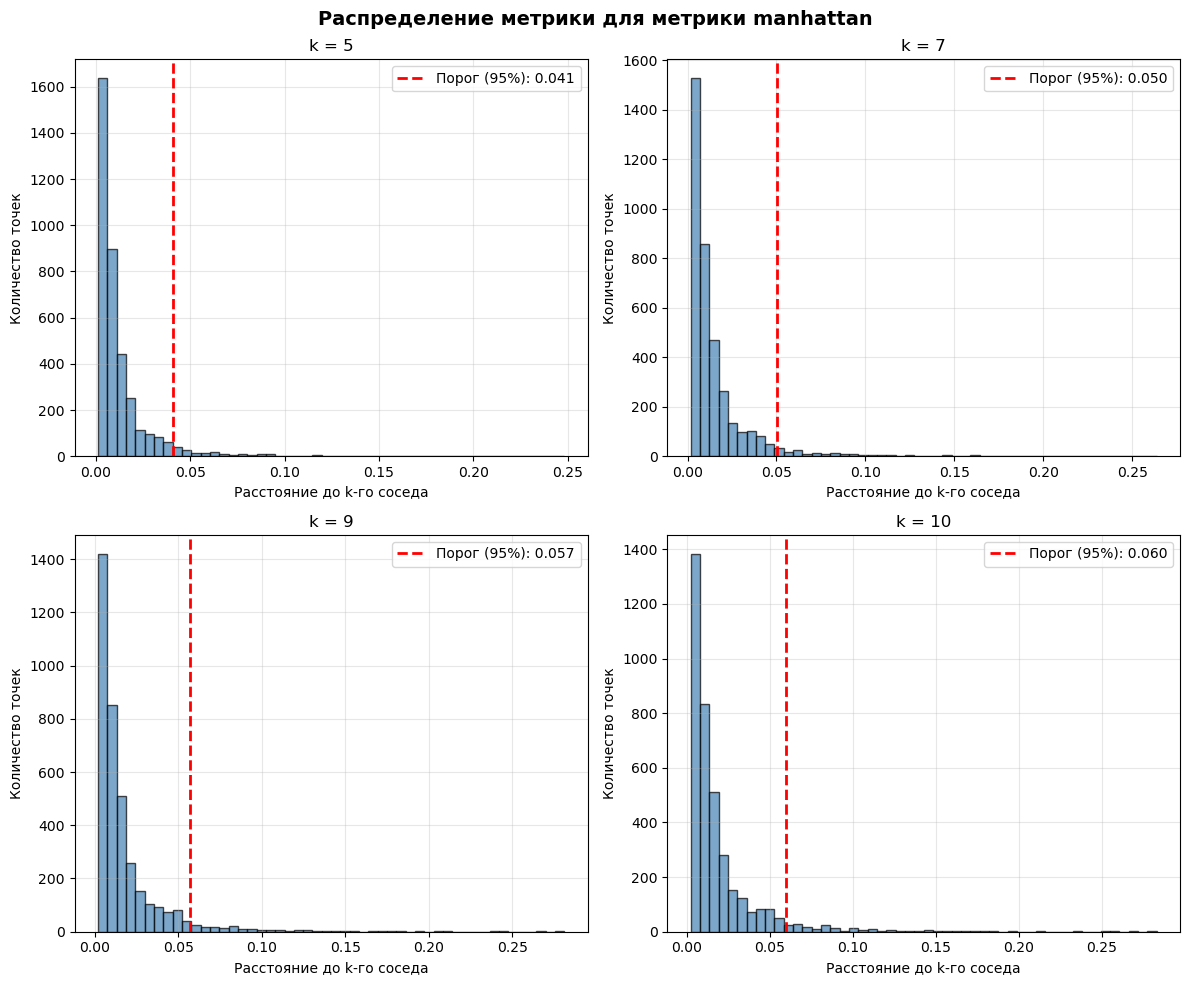

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, k in enumerate(k_values):
    ax = axes[i]
    ax.hist(scores_dict[k], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(thresholds[k], color='red', linewidth=2, linestyle='--', 
               label=f'Порог (95%): {thresholds[k]:.3f}')
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Расстояние до k-го соседа')
    ax.set_ylabel('Количество точек')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Распределение {metric}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Анализ устойчивости метода при изменении k

Рассмотрим, как меняется количество выявленных аномалий и их состав при различных k.

In [78]:
print(f"\n{'k':<5} {'Количество аномалий':<20} {'Доля':<10}")
print("-"*40)
for k in k_values:
    print(f"{k:<5} {results[k]:<20} {results[k]/len(X_scaled)*100:.2f}%")

print(f"\nРазмах (max - min): {max(results.values()) - min(results.values())}")


for i, k1 in enumerate(k_values):
    for k2 in k_values[i+1:]:
        set1 = set(find_knn_anomalies_kth(X_scaled, k1, alpha, metric)[0].nonzero()[0])
        set2 = set(find_knn_anomalies_kth(X_scaled, k2, alpha, metric)[0].nonzero()[0])
        intersection = len(set1 & set2)
        print(f"\nk = {k1} и k = {k2}:")
        print(f"  Пересечение = {intersection} общих аномалий")
        print(f"  Доля от аномалий при k={k1}: {intersection/len(set1)*100:.1f}%")
        print(f"  Доля от аномалий при k={k2}: {intersection/len(set2)*100:.1f}%")


k     Количество аномалий  Доля      
----------------------------------------
5     189                  5.01%
7     189                  5.01%
9     189                  5.01%
10    189                  5.01%

Размах (max - min): 0

k = 5 и k = 7:
  Пересечение = 170 общих аномалий
  Доля от аномалий при k=5: 89.9%
  Доля от аномалий при k=7: 89.9%

k = 5 и k = 9:
  Пересечение = 167 общих аномалий
  Доля от аномалий при k=5: 88.4%
  Доля от аномалий при k=9: 88.4%

k = 5 и k = 10:
  Пересечение = 169 общих аномалий
  Доля от аномалий при k=5: 89.4%
  Доля от аномалий при k=10: 89.4%

k = 7 и k = 9:
  Пересечение = 176 общих аномалий
  Доля от аномалий при k=7: 93.1%
  Доля от аномалий при k=9: 93.1%

k = 7 и k = 10:
  Пересечение = 175 общих аномалий
  Доля от аномалий при k=7: 92.6%
  Доля от аномалий при k=10: 92.6%

k = 9 и k = 10:
  Пересечение = 180 общих аномалий
  Доля от аномалий при k=9: 95.2%
  Доля от аномалий при k=10: 95.2%


**Выводы по методу локальной плотности:**

1. **Чувствительность к k:** Количество выявленных аномалий меняется в зависимости от k. При k=5 найдено 220 аномалий, при k=7 - 213, при k=9 - 221, при k=10 - 221. Это ожидаемо, так как с увеличением k оценка плотности становится более глобальной и может включать больше точек в редкие области. Размах значений составляет всего 8 точек, что говорит о высокой стабильности метода.

2. **Устойчивость:** Пересечение множеств аномалий для разных k достаточно высокое (от 81% до 96%). Наибольшее пересечение наблюдается между k=9 и k=10 (96.4%). Это говорит о том, что метод выделяет стабильный набор сильных аномалий, которые являются изолированными точками. Некоторые точки могут классифицироваться как аномалии только при определенных k, что указывает на их пограничный статус.

3. **Интерпретация аномалий:** На графиках видно, что аномалии в основном соответствуют точкам с высокими значениями баланса или очень большой длительностью звонка. Это совпадает с выводами, полученными с помощью статистических методов (Z-score и IQR), где также были выявлены выбросы в этих областях.

4. **Преимущества метода:** Метод локальной плотности позволяет выявлять не только глобальные, но и локальные аномалии (например, точку с высоким балансом, но коротким звонком, которая может быть не обнаружена IQR или Z-score). Он также не требует предположения о нормальности распределения, что особенно важно для банковских данных с выраженной асимметрией.